# 1. 데이터 분석 개요

## Step 1: 질문하기 (Ask questions)
데이터가 주어진 상태에서 질문을 할 수도 있고, 질문에 답할 수 있는 데이터를 수집할 수도 있다.

## Step 2: 데이터 랭글링 (Wrangle data)
- 데이터 랭글링 : 원자료(raw data)를 보다 쉽게 접근하고 분석할 수 있도록 데이터를 정리하고 통합하는 과정
(참고. 위키피디아)
- 세부적으로는 데이터의 수집(gather), 평가(assess), 정제(clean) 작업으로 나눌 수 있다.

## Step 3: 데이터 탐색 (Exploratory Data Analysis)
데이터의 패턴을 찾고, 관계를 시각화 하는 작업을 통해 데이터에 대한 직관을 극대화 한다.

## Step 4: 결론 도출 또는 예측 (Draw conclusions or make predictions)
- Step 3에서 분석한 내용을 근거로 질문에 대한 답과 결론을 도출 할 수 있다.
- 머신러닝 또는 통계 추정 과정을 거치게 되면 예측을 만들어 낼 수도 있다.

## Step 5: 결과 공유 (Communicate the results)
보고서, 이메일, 블로그 등 다양한 방법을 통해 발견한 통찰들을 공유할 수 있다.

# 2. Case Study

## 지능형 스마트팜(참외) 데이터
- [AI Hub 지능형 스마트팜(참외) 데이터](https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=&topMenu=&aihubDataSe=data&dataSetSn=71344)
- 참외 재배 시 발생하는 노균병, 흰가루병의 진단을 목적으로 노균병, 노균병유사, 흰가루병, 흰가루병유사, 정상 이미지를 인공지능 학습하여 질병과 질병의 유사 형상 및 정상 이미지를 비교해 질병의 정확한 진단을 가능하게 함

**base_info**
- image_name: 이미지 파일의 이름
- image_path: 이미지 파일의 경로
- description: 데이터셋의 설명
- url: 데이터셋 관련 URL (출처)
- version: 데이터셋 버전
- create_date: 데이터셋 생성 날짜

**corps_info**
- frm_id: 농장의 ID
- frm_name: 농장의 이름
- frm_lctn: 농장의 위치 (위도, 경도)
- indvd_code: 개별 식물의 코드
- cltvtn_typ_cd: 재배 유형 코드
- corps_name: 작물 이름
- vrty_name: 작물의 품종 이름
- set_meal_dt: 식사 세트 날짜 (비료나 물을 준 날짜)
- grdp_step: 생육 단계

**image**
- image_wdth: 이미지의 너비
- image_hght: 이미지의 높이
- ext_type: 이미지 파일의 확장자 (예: jpg)
- potogrf_dt: 사진 촬영 날짜 및 시간
- create_dt: 데이터 생성 날짜 및 시간
- creator_name: 데이터 생성자의 이름
- potogrf_lctn: 사진 촬영 위치 (위도, 경도)
- potogrf_angle: 사진 촬영 각도
- potogrf_dstnc: 사진 촬영 거리
- rsoltn: 이미지 해상도
- shttr_spd: 셔터 속도
- iso: ISO 감도
- white_balance: 화이트 밸런스 설정
- fcs_dstnc: 초점 거리
- flash_mode: 플래시 모드
- f_stop: 조리개 값
- expsr_time: 노출 시간
- day_section: 주간/야간 구분 (예: 주간, 야간)
- class_name: 병해 유형 이름

**environments**
각 환경 요소에 대한 데이터가 시간별로 기록

- evrmnt_id: 환경 데이터의 ID
- inr_tp: 내부 온도 (°C)
- inr_hd: 내부 습도 (%)
- co2: CO2 농도 (ppm)
- amnt_of_slr_rdt: 일사량 (W/m²)
- soil_ec: 토양 전기 전도도 (dS/m)
- soil_tp: 토양 온도 (°C)
- soil_hd: 토양 습도 (%)
- rain: 강수 유무
- extrnl_tp: 외부 온도 (°C)
- extrnl_hd: 외부 습도 (%)
- receive_dt: 데이터 수신 시간
  
**licenses**
- licenses_id: 라이선스 ID
- licenses_name: 라이선스 이름
- licenses_url: 라이선스 URL

## Step 1: 질문하기 (Ask questions)

**예시**
- (질문 1) 특정 병해(예: 노균병)가 발생하는 조건은 무엇인가?
- (질문 2) 작물의 특정 생장 단계에서 주로 발생하는 병해는 무엇인가?
- (질문 3) 특정 병해를 예방하기 위한 최적의 관리 전략은 무엇인가?

## Step 2: 데이터 랭글링 (Wrangle data)

In [1]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Malgun Gothic'  # (Windows 용)
warnings.filterwarnings("ignore", category=FutureWarning)

- 이미지 데이터 시각화

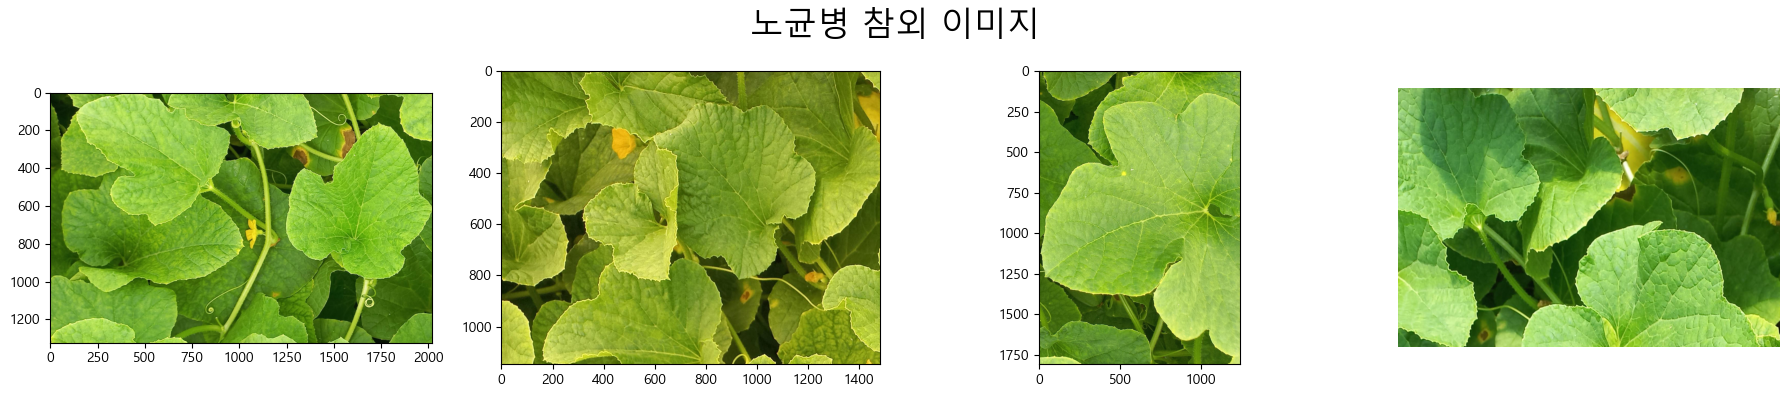

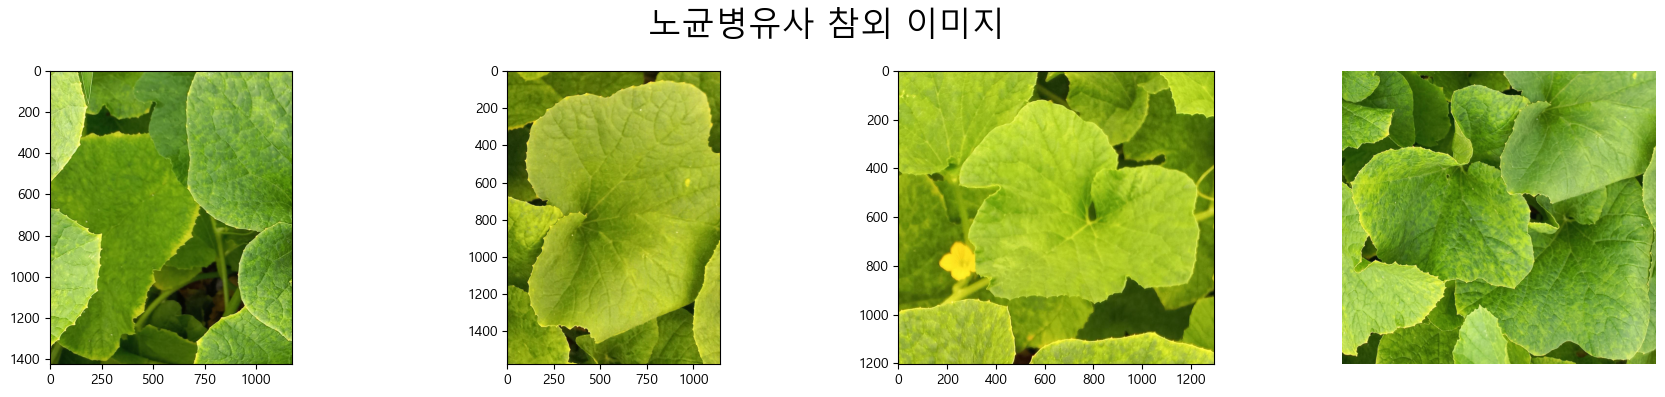

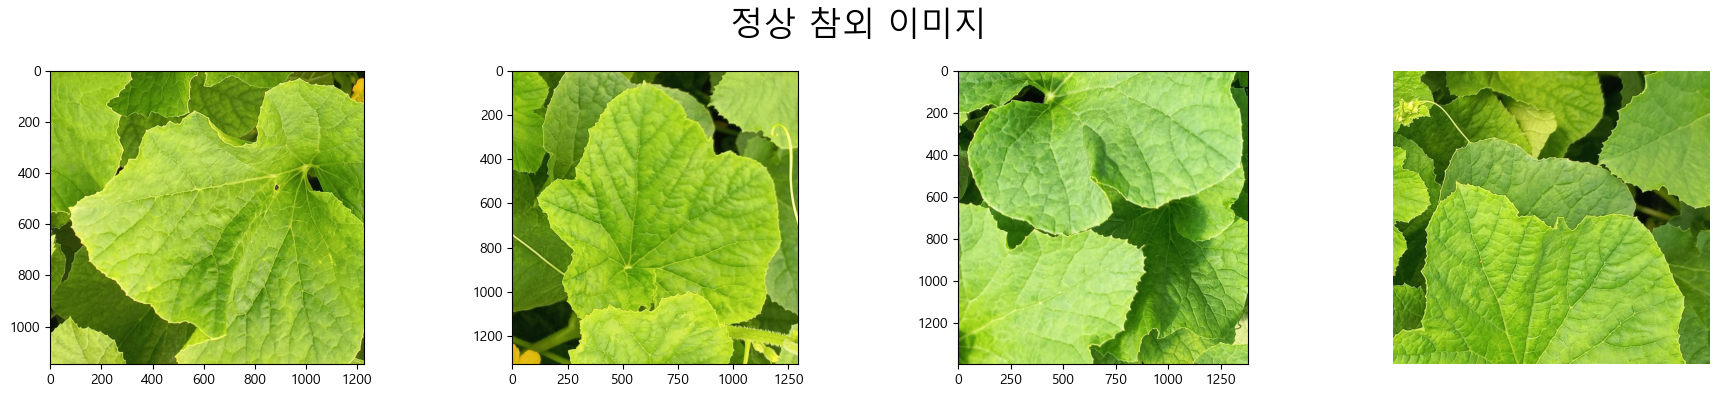

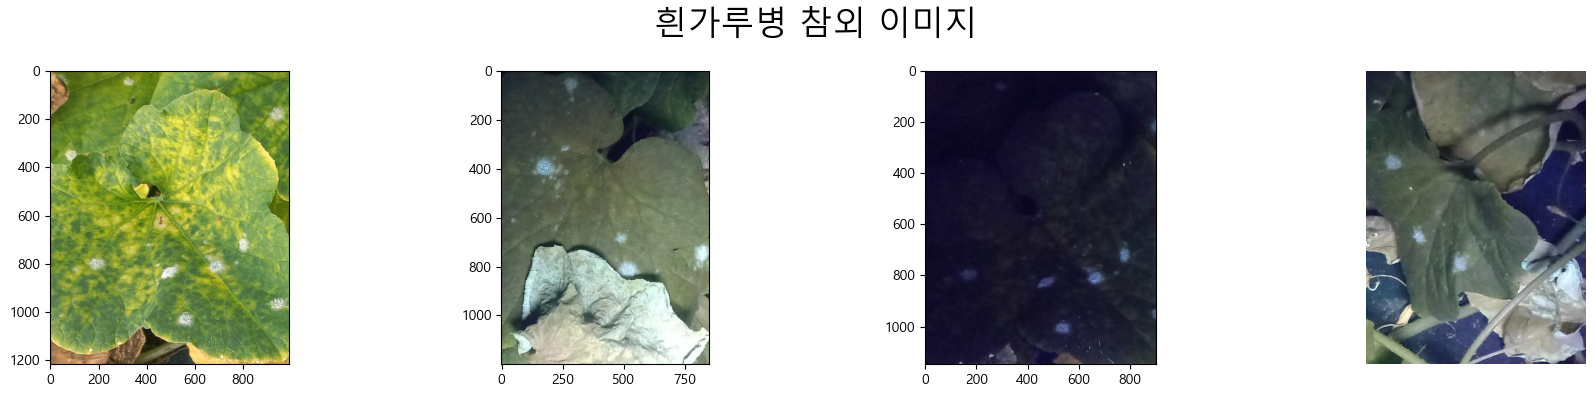

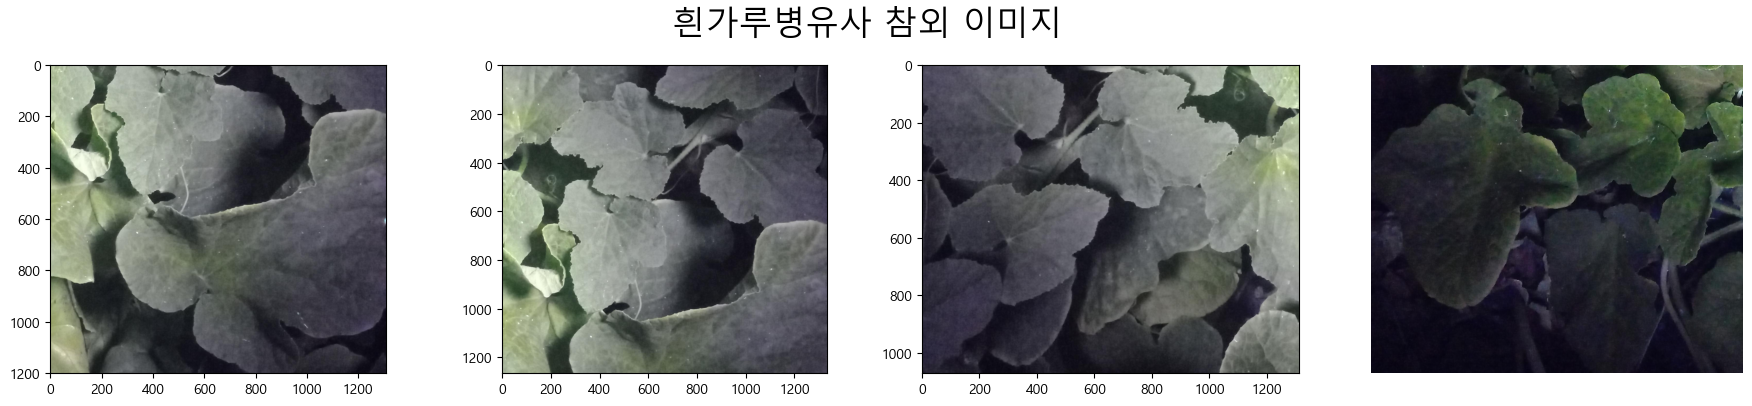

In [2]:
root_dir = './'
image_dir = '01.원천데이터/'
label_dir = '02.라벨링데이터/'
directories = ['노균병', '노균병유사', '정상', '흰가루병', '흰가루병유사']

for directory in directories:
    class_image_dir = root_dir + image_dir + directory
    class_image_paths = glob.glob(class_image_dir + '/*.jpg')

    figure, axes = plt.subplots(figsize=(18, 4), nrows=1, ncols=4)
    figure.suptitle(f'{directory} 참외 이미지', fontsize=24)

    for i in range(4):
        image = plt.imread(class_image_paths[i])
        axes[i].imshow(image)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

- 메타 데이터 적재

In [3]:
for directory in directories:
    class_label_dir = root_dir + label_dir + directory
    class_label_paths = glob.glob(class_label_dir + '/*.json')

    with open(class_label_paths[0], 'r', encoding='utf-8') as f:
        metadata = json.load(f)

        # 환경 정보 및 클래스 정보만 출력
        if 'environments' in metadata:
            print(f"{directory} 참외의 환경 정보:")
            print(json.dumps(metadata['environments'], indent=4, ensure_ascii=False))
        if 'class_name' in metadata['image']:
            print(f"{directory} 참외의 클래스 정보:", metadata['image']['class_name'])
            print()

노균병 참외의 환경 정보:
[
    {
        "evrmnt_id": 0,
        "inr_tp": 40.7,
        "inr_hd": 49.3,
        "co2": 389,
        "amnt_of_slr_rdt": 218,
        "soil_ec": 0.38,
        "soil_tp": 30.6,
        "soil_hd": 26.7,
        "rain": "맑음",
        "extrnl_tp": 27.0,
        "extrnl_hd": 75.0,
        "receive_dt": "2022-07-05 12:00:00"
    },
    {
        "evrmnt_id": 1,
        "inr_tp": 39.7,
        "inr_hd": 56.9,
        "co2": 394,
        "amnt_of_slr_rdt": 314,
        "soil_ec": 0.37,
        "soil_tp": 30.8,
        "soil_hd": 26.4,
        "rain": "맑음",
        "extrnl_tp": 27.0,
        "extrnl_hd": 75.0,
        "receive_dt": "2022-07-05 12:30:00"
    }
]
노균병 참외의 클래스 정보: 노균병

노균병유사 참외의 환경 정보:
[
    {
        "evrmnt_id": 1,
        "inr_tp": 39.7,
        "inr_hd": 53.4,
        "co2": 377,
        "amnt_of_slr_rdt": 236,
        "soil_ec": 0.08,
        "soil_tp": 30.9,
        "soil_hd": 16.6,
        "rain": "맑음",
        "extrnl_tp": 24.0,
        "extrnl_hd": 85.

- 모든 메타 파일을 로드하여 리스트에 저장

In [4]:
json_files = glob.glob(label_dir + '/*/*.json')
data_list = []

for file in json_files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        base_info = data['base_info']
        corps_info = data['corps_info']
        image_info = data['image']
        environments = data['environments']

        for env in environments:
            combined_data = {**base_info, **corps_info, **image_info, **env}
            data_list.append(combined_data)

# 데이터 프레임으로 변환
df = pd.DataFrame(data_list)

In [5]:
# 원본 데이터프레임
df.head(2).T

,0,1
image_name,S011-FM01-011-2022-07-05-000035.jpg,S011-FM01-011-2022-07-05-000035.jpg
image_path,E:/1cycle_1212/work/DATA_SET/validation/노균병/im...,E:/1cycle_1212/work/DATA_SET/validation/노균병/im...
description,참외 질병 2022 Dataset,참외 질병 2022 Dataset
url,https://aihub.or.kr/,https://aihub.or.kr/
version,1.0,1.0
create_date,2022-06-07,2022-06-07
frm_id,FM01,FM01
frm_name,춘종묘 A 농장,춘종묘 A 농장
frm_lctn,"35.9189993,128.2894434","35.9189993,128.2894434"
indvd_code,S011,S011


- 데이터 수집

In [7]:
# 분석에 필요한 컬럼만 선별해서 저장

# 환경 요소에 대한 데이터
# environments = ["evrmnt_id", "inr_tp", "inr_hd", "co2", "amnt_of_slr_rdt", 
#                          "soil_ec", "soil_tp", "soil_hd", "rain", "extrnl_tp", "extrnl_hd", "receive_dt"]
start_idx = np.where(df.columns == 'inr_tp')[0][0]
environments = list(df.columns[start_idx : ])
selected_columns = ['class_name', 'grdp_step'] + environments

# 새로운 데이터프레임 생성
melon = df[selected_columns].copy()

# 컬럼명을 한글로 바꿈
melon.columns = [
    '병해 유형', '생육 단계', 
    '내부 온도', '내부 습도', 'CO2 농도', '일사량', 
    '토양 전기 전도도', '토양 온도', '토양 습도', '강수 유무', 
    '외부 온도', '외부 습도', '데이터 수신시간'
]

# 데이터프레임을 CSV 파일로 저장
melon.to_csv('environment_melon_data.csv', index=False)

- 데이터 평가

In [8]:
melon.shape

(7280, 13)

In [9]:
melon.head(3)

,병해 유형,생육 단계,내부 온도,내부 습도,CO2 농도,일사량,토양 전기 전도도,토양 온도,토양 습도,강수 유무,외부 온도,외부 습도,데이터 수신시간
0,노균병,정식,40.7,49.3,389,218,0.38,30.6,26.7,맑음,27.0,75.0,2022-07-05 12:00:00
1,노균병,정식,39.7,56.9,394,314,0.37,30.8,26.4,맑음,27.0,75.0,2022-07-05 12:30:00
2,노균병,정식,26.4,85.9,423,28,0.18,30.2,21.6,맑음,33.0,50.0,2022-07-06 06:00:00


In [10]:
melon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7280 entries, 0 to 7279
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   병해 유형      7280 non-null   object 
 1   생육 단계      7280 non-null   object 
 2   내부 온도      7280 non-null   float64
 3   내부 습도      7280 non-null   float64
 4   CO2 농도     7280 non-null   int64  
 5   일사량        7280 non-null   int64  
 6   토양 전기 전도도  7280 non-null   float64
 7   토양 온도      7280 non-null   float64
 8   토양 습도      7280 non-null   float64
 9   강수 유무      7280 non-null   object 
 10  외부 온도      7280 non-null   float64
 11  외부 습도      7280 non-null   float64
 12  데이터 수신시간   7280 non-null   object 
dtypes: float64(7), int64(2), object(4)
memory usage: 739.5+ KB


- 데이터 정제 (누락된 값 처리, 잘못된 데이터 타입)

In [11]:
melon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7280 entries, 0 to 7279
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   병해 유형      7280 non-null   object 
 1   생육 단계      7280 non-null   object 
 2   내부 온도      7280 non-null   float64
 3   내부 습도      7280 non-null   float64
 4   CO2 농도     7280 non-null   int64  
 5   일사량        7280 non-null   int64  
 6   토양 전기 전도도  7280 non-null   float64
 7   토양 온도      7280 non-null   float64
 8   토양 습도      7280 non-null   float64
 9   강수 유무      7280 non-null   object 
 10  외부 온도      7280 non-null   float64
 11  외부 습도      7280 non-null   float64
 12  데이터 수신시간   7280 non-null   object 
dtypes: float64(7), int64(2), object(4)
memory usage: 739.5+ KB


## Step 3: 데이터 탐색 (Exploratory Data Analysis)


**질문 1** : 특정 병해(예: 노균병)가 발생하는 조건은 무엇인가?
- 병해 발생에 환경 조건(온도, 습도, CO2 농도 등)은 어떤 영향을 미치는가?

**참고**
- 병해 종류 : 범주형 데이터
- 환경 조건(온도, 습도, CO2 농도 등) : 수치형 데이터
- 범주형 데이터 값에 따라 수치형 데이터가 어떻게 달라지는 파악할 때 막대그래프(barplot)

In [12]:
melon.columns

Index(['병해 유형', '생육 단계', '내부 온도', '내부 습도', 'CO2 농도', '일사량', '토양 전기 전도도',
       '토양 온도', '토양 습도', '강수 유무', '외부 온도', '외부 습도', '데이터 수신시간'],
      dtype='object')

- 병해 유형 분포

In [13]:
melon['병해 유형'].value_counts()

병해 유형
정상        3040
노균병       1460
흰가루병      1460
노균병유사      660
흰가루병유사     660
Name: count, dtype: int64

<Axes: xlabel='병해 유형', ylabel='count'>

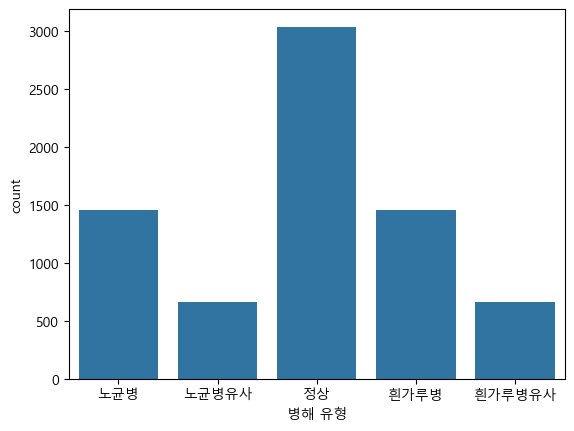

In [14]:
sns.countplot(data=melon, x='병해 유형')

- 환경 조건중 수치 데이터의 통계

In [15]:
env_factors = ['내부 온도', '내부 습도', 'CO2 농도', '일사량', '토양 전기 전도도', 
               '토양 온도', '토양 습도', '외부 온도', '외부 습도']

In [16]:
melon[env_factors].describe() # 외부 온도와 외부 습도에 이상치가 존재함

,내부 온도,내부 습도,CO2 농도,일사량,토양 전기 전도도,토양 온도,토양 습도,외부 온도,외부 습도
count,7280.000000,7280.000000,7280.000000,7280.000000,7280.000000,7280.000000,7280.000000,7280.000000,7280.000000
mean,29.744409,70.145701,451.483654,122.190247,0.310272,28.126442,23.377596,21.840179,67.311538
std,8.786040,21.930567,202.454348,160.459740,0.347421,3.284812,9.344153,56.452307,60.798577
min,5.500000,13.100000,169.000000,-10.000000,0.020000,18.600000,11.800000,-999.000000,-998.000000
25%,24.700000,51.100000,370.000000,0.000000,0.090000,25.600000,17.200000,22.300000,60.000000
50%,27.300000,78.100000,411.000000,39.000000,0.140000,29.100000,20.900000,26.000000,75.000000
75%,35.225000,88.600000,459.000000,225.000000,0.390000,30.500000,25.600000,28.000000,84.000000
max,57.400000,100.000000,2567.000000,822.000000,1.180000,37.700000,47.900000,36.000000,100.000000


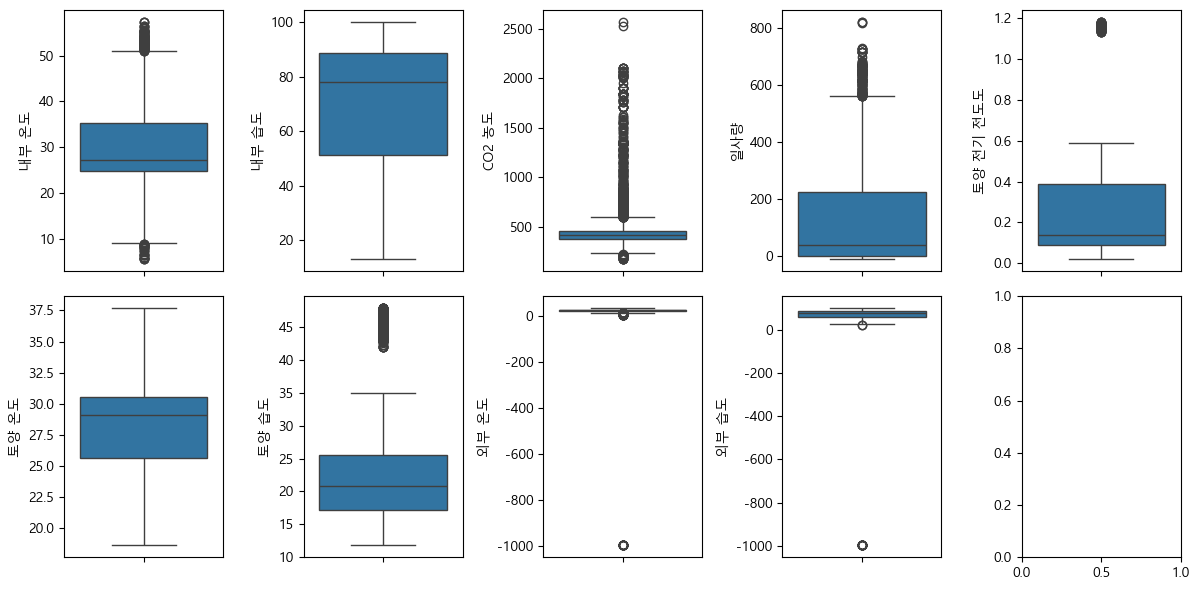

In [17]:
# 박스 플롯으로 시각화로 재확인
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 6))
axes = axes.flatten()
for i, column in enumerate(env_factors):
    sns.boxplot(data=melon, y=melon[column], ax=axes[i])
plt.tight_layout()     

- 결측치 제거

In [18]:
(melon['외부 온도'] == -999).sum()

22

In [19]:
(melon['외부 습도'] == -998).sum()

22

In [20]:
melon = melon[melon['외부 온도'] != -999]
melon = melon[melon['외부 습도'] != -998]

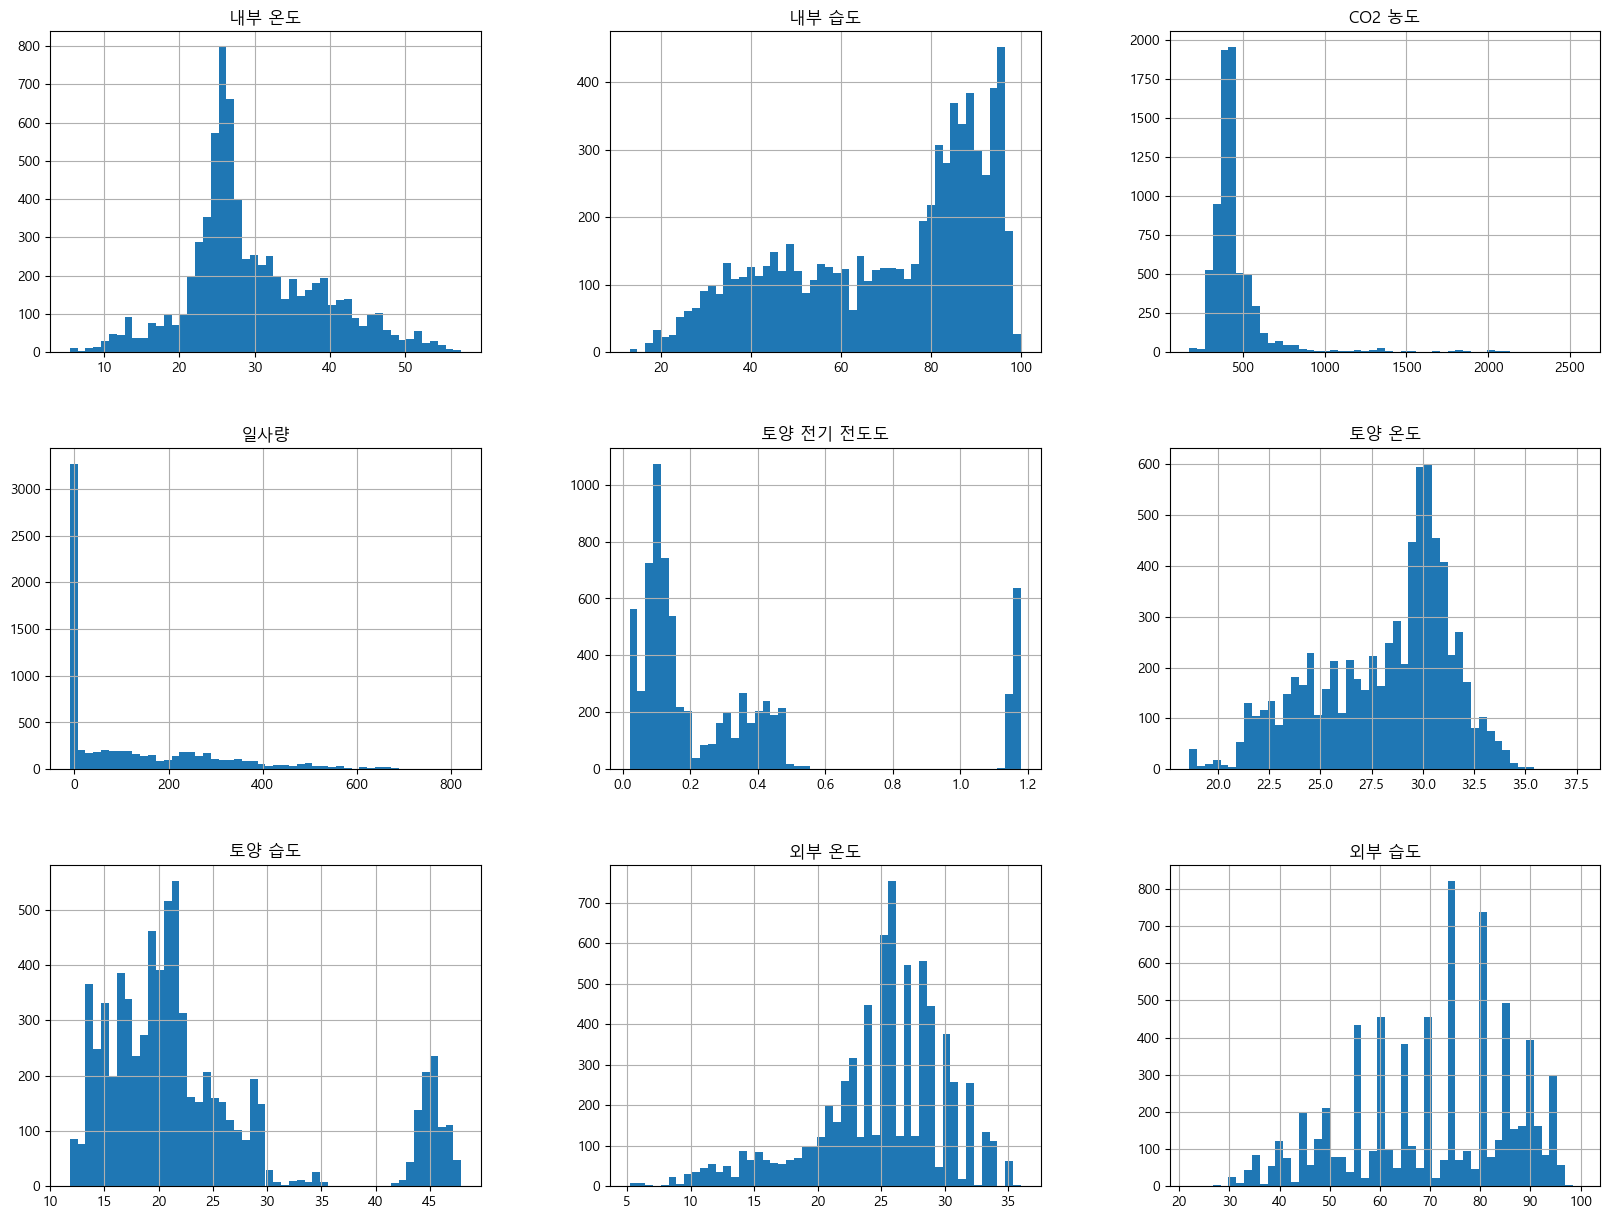

In [21]:
melon[env_factors].hist(figsize=(20, 15), bins=50)
plt.show()

- 노균병 vs 정상 상태

In [22]:
specific_disease = '노균병'
disease_data = melon[melon['병해 유형'] == specific_disease]
normal_data = melon[melon['병해 유형'] == '정상']

# Combine the disease and normal data for comparison
combined_data = pd.concat([disease_data, normal_data])

In [23]:
combined_data['병해 유형'].value_counts()

병해 유형
정상     3040
노균병    1452
Name: count, dtype: int64

In [24]:
disease_data.describe()

,내부 온도,내부 습도,CO2 농도,일사량,토양 전기 전도도,토양 온도,토양 습도,외부 온도,외부 습도
count,1452.000000,1452.000000,1452.000000,1452.000000,1452.000000,1452.000000,1452.000000,1452.000000,1452.000000
mean,33.800551,61.598072,481.097796,206.184573,0.131343,25.338774,19.991667,24.751791,65.889807
std,8.688718,22.580848,384.486578,164.852917,0.073420,3.041057,4.080311,4.338281,17.494084
min,10.100000,17.300000,169.000000,-7.000000,0.030000,18.600000,11.800000,10.800000,25.000000
25%,27.775000,43.200000,321.000000,65.750000,0.100000,23.400000,17.800000,22.000000,51.000000
50%,33.700000,58.200000,359.000000,184.500000,0.120000,25.100000,20.100000,25.000000,65.000000
75%,39.900000,84.025000,404.000000,299.000000,0.150000,27.000000,21.325000,28.000000,80.250000
max,55.600000,100.000000,2567.000000,732.000000,0.550000,34.600000,35.000000,36.000000,96.000000


In [25]:
normal_data.describe()

,내부 온도,내부 습도,CO2 농도,일사량,토양 전기 전도도,토양 온도,토양 습도,외부 온도,외부 습도
count,3040.000000,3040.000000,3040.000000,3040.000000,3040.000000,3040.000000,3040.000000,3040.000000,3040.000000
mean,30.282434,73.490691,415.167105,95.613816,0.179253,30.523553,20.095000,27.716250,68.529934
std,7.385866,19.540922,68.455511,158.913372,0.139791,1.313608,5.145061,3.137637,13.626490
min,20.200000,22.700000,254.000000,0.000000,0.030000,22.800000,11.800000,19.000000,35.000000
25%,25.500000,59.275000,389.000000,0.000000,0.070000,29.700000,15.700000,25.000000,60.000000
50%,26.800000,80.300000,412.000000,0.000000,0.120000,30.400000,19.400000,27.000000,70.000000
75%,33.100000,88.800000,437.500000,143.500000,0.300000,31.300000,24.400000,30.000000,80.000000
max,56.600000,98.200000,620.000000,822.000000,0.540000,34.700000,33.100000,36.000000,95.000000


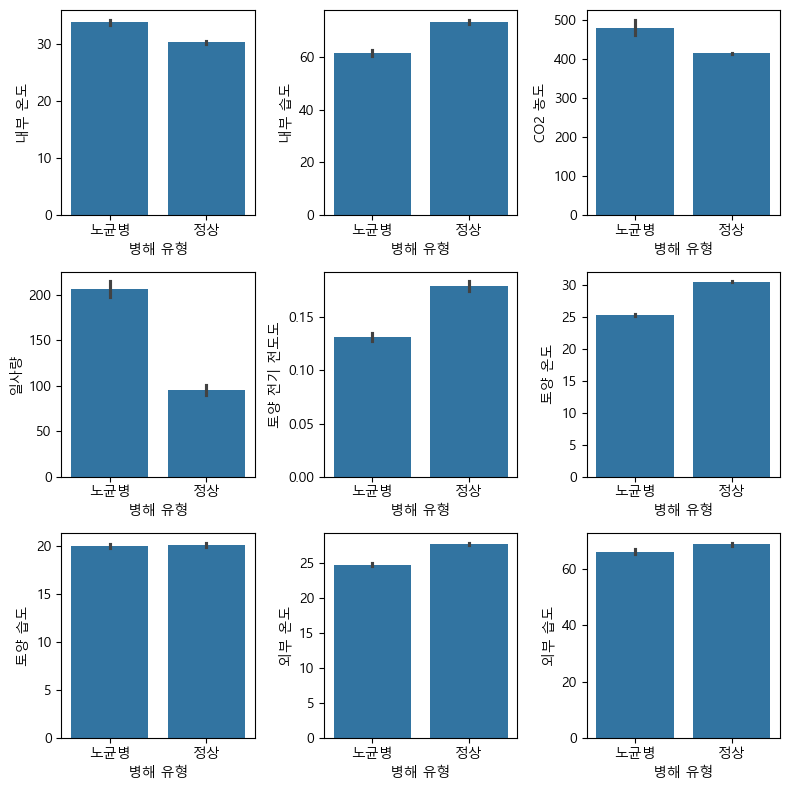

In [26]:
# 평균
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

axes = axes.flatten()
for i, env_factor in enumerate(env_factors):
    sns.barplot(data=combined_data, x='병해 유형', y=env_factor, ax=axes[i])

plt.tight_layout()
plt.show()

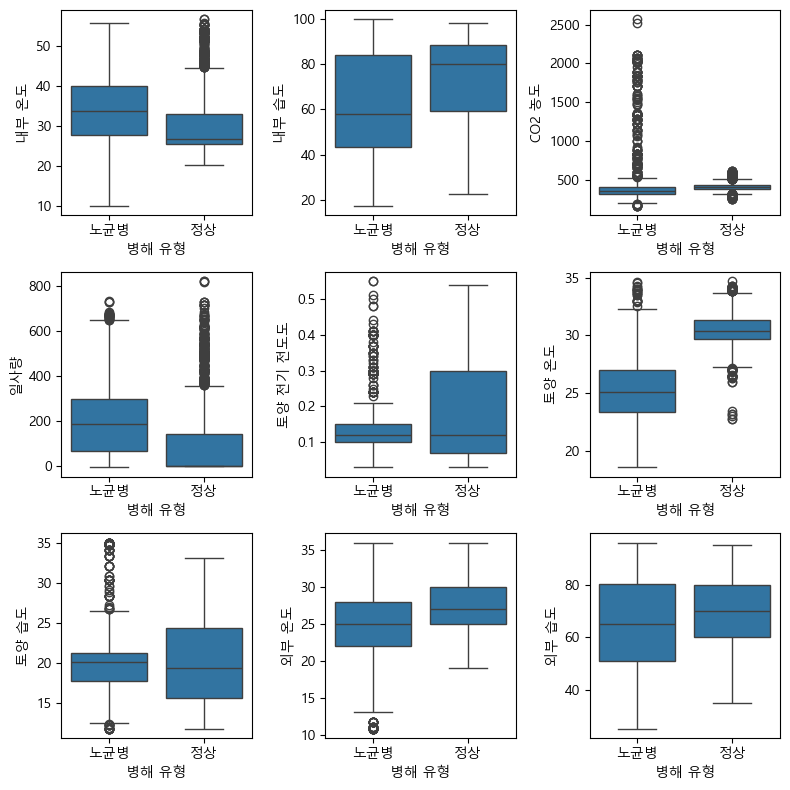

In [27]:
# 사분위 분포
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

axes = axes.flatten()
for i, env_factor in enumerate(env_factors):
    sns.boxplot(data=combined_data, x='병해 유형', y=env_factor, ax=axes[i])

plt.tight_layout()
plt.show()

**분석 결과**

**1. 내부 온도:**
- 노균병 그룹 평균(33.80°C)이 정상 그룹(30.28°C)보다 약 3.5°C 높음
- 노균병 그룹의 표준편차(8.69)가 정상 그룹(7.39)보다 더 크며, 이는 온도 변동이 더 심함

**2. 내부 습도:**
- 노균병 그룹 평균(61.60%)이 정상 그룹(73.49%)보다 낮음
- 노균병 그룹의 표준편차(22.58)가 정상 그룹(19.54)보다 더 크며, 습도 변동이 더 심함

**3. CO2 농도:**
- 노균병 그룹 평균(481.10 ppm)이 정상 그룹(415.17 ppm)보다 높음
- 노균병 그룹의 표준편차(384.49)가 정상 그룹(68.46)보다 훨씬 더 크며, CO2 농도 변동이 매우 심함

**4. 일사량:**
- 노균병 그룹 평균(206.18)이 정상 그룹(95.61)보다 2배 이상 높음
- 두 그룹 모두 표준편차가 크지만, 노균병 그룹(164.85)이 정상 그룹(158.91)보다 약간 더 큼

**5. 토양 전기 전도도:**
- 노균병 그룹 평균(0.13)이 정상 그룹(0.18)보다 낮음
- 정상 그룹의 표준편차(0.14)가 노균병 그룹(0.07)보다 2배 정도 큼

**6. 토양 온도:**
- 노균병 그룹 평균(25.34°C)이 정상 그룹(30.52°C)보다 낮음
- 노균병 그룹의 표준편차(3.04)가 정상 그룹(1.31)보다 2배 이상 큼

**7. 토양 습도:**
- 두 그룹의 평균이 비슷함(노균병: 19.99%, 정상: 20.10%).
- 노균병 그룹의 표준편차(4.08)가 정상 그룹(5.15)보다 약간 작음

**8. 외부 온도와 습도:**
- 외부 온도와 습도는 두 그룹 간에 큰 차이가 없음

**결론**
- 노균병 그룹은 정상 그룹에 비해 내부 온도가 높고, 내부 습도가 낮으며, CO2 농도와 일사량이 높은 경향
- 대부분의 요인에서 노균병 그룹의 변동성이 더 큰 것으로 나타남
- 이러한 환경적 차이들이 노균병 발생과 관련이 있을 수 있음
---

**질문 2** : 작물의 특정 생장 단계에서 주로 발생하는 병해는 무엇인가?

**정식 (Transplanting):**
- 정식은 모종을 밭에 옮겨 심는 단계입니다. 이는 씨앗을 파종한 후, 묘목을 일정 기간 동안 키워서 밭에 옮겨 심는 과정을 말합니다. 이 단계에서는 작물이 뿌리를 내리고 새로운 환경에 적응하는 시기입니다.

**착과 (Fruit Setting):**
- 착과는 작물이 꽃을 피우고, 그 꽃이 열매를 맺기 시작하는 단계입니다. 이 시기에는 열매가 형성되고, 이후 자라면서 성숙해집니다. 이 단계에서의 환경 조건은 열매의 품질과 수확량에 큰 영향을 미칩니다.

**수확 (Harvesting):**
- 수확은 작물이 성숙하여 열매를 수확하는 단계입니다. 이 시기는 작물의 생장 주기 중 마지막 단계로, 수확 시기의 환경 조건은 작물의 최종 품질에 중요한 영향을 미칩니다.

In [28]:
melon.columns

Index(['병해 유형', '생육 단계', '내부 온도', '내부 습도', 'CO2 농도', '일사량', '토양 전기 전도도',
       '토양 온도', '토양 습도', '강수 유무', '외부 온도', '외부 습도', '데이터 수신시간'],
      dtype='object')

In [29]:
# 1. 생장 단계별 병해 발생 빈도 계산
disease_by_stage = pd.crosstab(melon['생육 단계'], melon['병해 유형'])
disease_by_stage

병해 유형,노균병,노균병유사,정상,흰가루병,흰가루병유사
생육 단계,,,,,
수확,946,0,0,1432,22
정식,226,92,2950,0,36
착과,280,568,90,14,602


In [30]:
disease_by_stage.sum(axis=1)

생육 단계
수확    2400
정식    3304
착과    1554
dtype: int64

In [31]:
# 2. 각 생장 단계별 비율 계산
disease_rate_by_stage = disease_by_stage.div(disease_by_stage.sum(axis=1), axis=0)
disease_rate_by_stage

병해 유형,노균병,노균병유사,정상,흰가루병,흰가루병유사
생육 단계,,,,,
수확,0.394167,0.000000,0.000000,0.596667,0.009167
정식,0.068402,0.027845,0.892857,0.000000,0.010896
착과,0.180180,0.365508,0.057915,0.009009,0.387387


In [32]:
# 3. 결과 출력
print("각 생장 단계별 병해 발생 비율:")
disease_rate_by_stage.round(4) # 소수점 4자리까지 반올림

각 생장 단계별 병해 발생 비율:


병해 유형,노균병,노균병유사,정상,흰가루병,흰가루병유사
생육 단계,,,,,
수확,0.3942,0.0000,0.0000,0.5967,0.0092
정식,0.0684,0.0278,0.8929,0.0000,0.0109
착과,0.1802,0.3655,0.0579,0.0090,0.3874


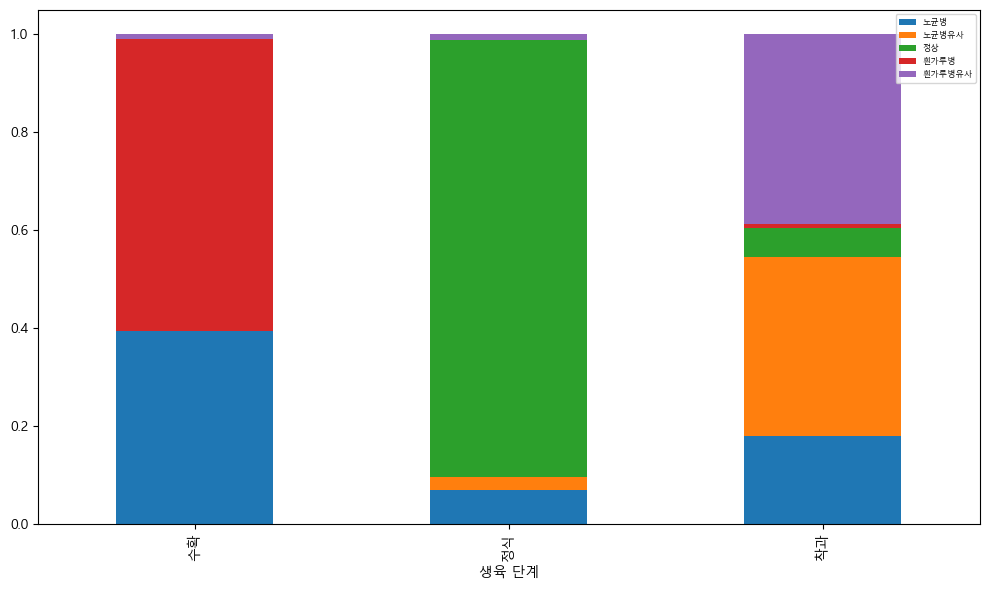

In [33]:
# 4. 시각화: 생장 단계별 병해 발생률 막대 그래프
disease_rate_by_stage.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.legend(loc='best', prop={'size': 6})
plt.tight_layout()
plt.show()

In [34]:
# 5. 각 생장 단계별 가장 흔한 병해와 그 발생률
most_common_disease = disease_rate_by_stage.idxmax(axis=1)
most_common_disease_rate = disease_rate_by_stage.max(axis=1)

print("각 생장 단계별 가장 흔한 병해와 그 발생률:\n")
for stage, disease in most_common_disease.items():
    rate = most_common_disease_rate[stage]
    print(f"{stage}: {disease} ({rate:.2%})")

각 생장 단계별 가장 흔한 병해와 그 발생률:

수확: 흰가루병 (59.67%)
정식: 정상 (89.29%)
착과: 흰가루병유사 (38.74%)


**분석 결과**
- 수확 단계: 흰가루병이 가장 흔하며, 전체 병해의 59.70%를 차지
- 정식 단계: 대부분(89.29%)이 정상 상태
- 착과 단계: 흰가루병유사 증상이 가장 많이 나타나며, 38.74%를 차지

## Step 4: 결론 도출 또는 예측 (Draw conclusions or make predictions)


- 질문 1, 질문 2에 대한 분석 결과를 바탕으로 결론을 도출한다.
- 질문 3 특정 병해를 예방하기 위한 최적의 관리 전략을 수립한다.

## Step 5: 결과 공유 (Communicate the results)

- 병해의 원인을 예측할 때 고려해야할 중요한 특성을 설명하는 보고서, PPT 등을 준비